# **Instructor Effectiveness Modeling (EdTech Context)**

## Part 5: Evaluation of the Model

Accuracy, per-class precision / recall / F1, the confusion matrix, and the reasoning behind those metric choices.

**Notebooks in this project:**

1. `01_Data_Ingestion_and_Preparation.ipynb`
2. `02_Data_Interpretation_and_EDA.ipynb`
3. `03_Instructor_Level_Aggregation.ipynb`
4. `04_Machine_Learning_Model.ipynb`
5. `05_Model_Evaluation.ipynb` &nbsp;&larr; *you are here*
6. `06_Interpretation_and_Analysis_Questions.ipynb`

---

> **Setup cell (added when the original single notebook was split).** Run this first so the notebook works standalone.


In [ ]:
# --- Setup: load the trained model and test split produced in Part 4 ---
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import joblib
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

ARTIFACTS = 'artifacts'
path = os.path.join(ARTIFACTS, 'model_bundle.joblib')
assert os.path.exists(path), 'Run 04_Machine_Learning_Model.ipynb first.'

bundle = joblib.load(path)
model         = bundle['model']
feature_cols  = bundle['feature_cols']
X_test_scaled = bundle['X_test_scaled']
y_test        = bundle['y_test']

y_pred = model.predict(X_test_scaled)
print('Loaded model. Test size:', len(y_test))

# Part5. **Evaluation of the model:**

In [110]:
print('Accuracy:', round(accuracy_score(y_test, y_pred), 3))
print()
print(classification_report(y_test, y_pred))

Accuracy: 0.967

              precision    recall  f1-score   support

        High       0.91      1.00      0.95        10
         Low       1.00      1.00      1.00        10
      Medium       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



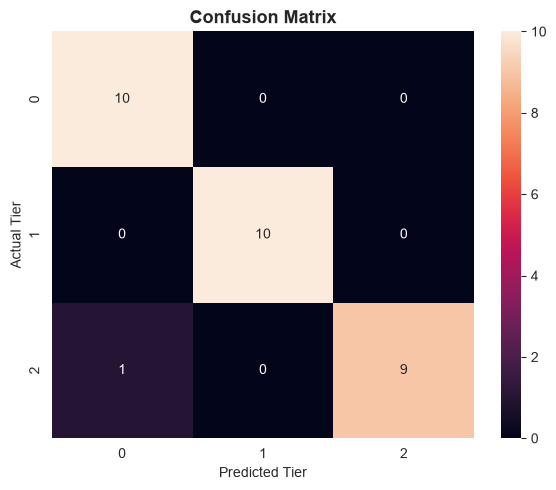

In [111]:
# Let's plot an confusion metrics:
cm = confusion_matrix(y_test, y_pred,)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True)
plt.xlabel('Predicted Tier')
plt.ylabel('Actual Tier')
plt.title('Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Metric choice & trade-offs:**
* We report **accuracy**, and **per-class precision/recall/F1**, since this is a balanced 3-class problem (40/40/40 by construction) — accuracy is meaningful here specifically *because* there's no class imbalance.


* **Precision vs. recall matters differently by tier in a real product**: for the **Low** tier, we'd rather prioritize **recall** (catch every genuinely underperforming instructor, even if a few Medium instructors get flagged too) since missing a struggling instructor has a bigger downside than a false alarm. For the **High** tier, **precision** matters more (don't want to mistakenly reward/promote an instructor who isn't truly top-performing).

* **Class imbalance:** none present — the tertile-based tiering in Step 2 guarantees equal class sizes, so we didn't need techniques like class weighting, SMOTE, or stratified resampling here.
